In [9]:
import sys
sys.path.append("..")  # so we can import pricer from the notebooks/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

from pricer.implied_vol import implied_vol

In [4]:
ticker = yf.Ticker("AAPL")
S = ticker.history(period="1d")["Close"].iloc[-1]
print(f"Spot: {S:.2f}")

expirations = ticker.options
expiry = expirations[3]   # pick the 4th listed expiry
print(f"Expiry: {expiry}")

chain = ticker.option_chain(expiry)
calls = chain.calls.copy()
puts = chain.puts.copy()
print(f"Calls: {len(calls)}, Puts: {len(puts)}")

Spot: 337.02
Expiry: 2026-10-02
Calls: 59, Puts: 57


In [5]:
today = datetime.today()
expiry_dt = datetime.strptime(expiry, "%Y-%m-%d")
T = (expiry_dt - today).days / 365.0
print(f"T = {T:.4f} years ({int((expiry_dt - today).days)} days)")

T = 0.0219 years (8 days)


In [6]:
r = 0.05   # approximation; could pull a T-bill yield for accuracy
q = 0.0    # AAPL pays a small dividend, but this is a fine first pass

def iv_row(row, opt_type):
    K = row["strike"]
    bid, ask = row["bid"], row["ask"]
    if bid <= 0 or ask <= 0:
        return np.nan
    mid = 0.5 * (bid + ask)
    try:
        return implied_vol(mid, S, K, T, r, q, opt_type)
    except Exception:
        return np.nan

calls["iv"] = calls.apply(lambda r: iv_row(r, "call"), axis=1)
puts["iv"] = puts.apply(lambda r: iv_row(r, "put"), axis=1)

print(f"Calls with IV: {calls['iv'].notna().sum()} / {len(calls)}")
print(f"Puts  with IV: {puts['iv'].notna().sum()} / {len(puts)}")

Calls with IV: 27 / 59
Puts  with IV: 36 / 57


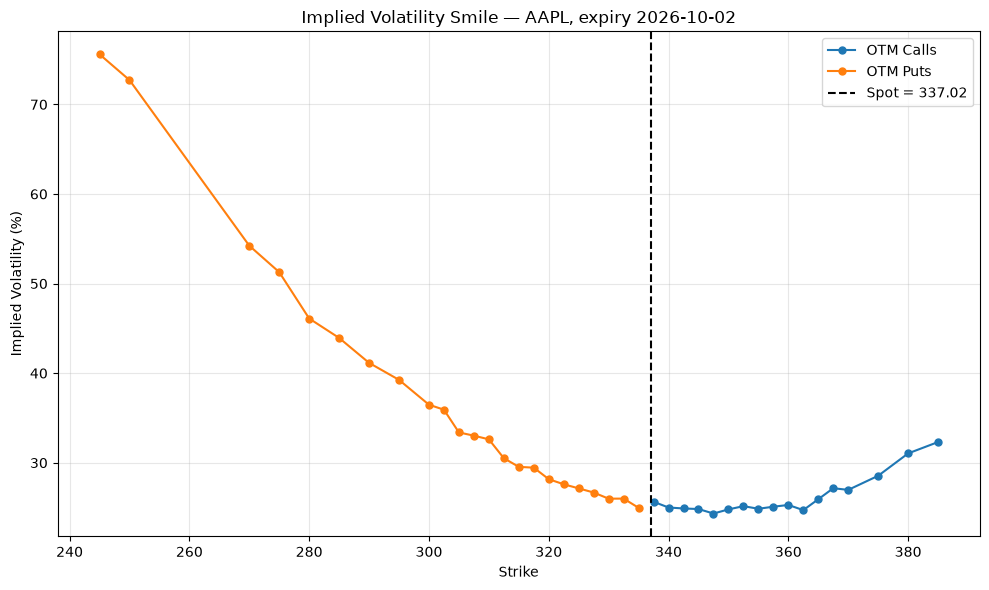

In [7]:
# Use OTM options only: calls above spot, puts below spot
otm_calls = calls[(calls["strike"] > S) & calls["iv"].notna()]
otm_puts  = puts[(puts["strike"] < S) & puts["iv"].notna()]

plt.figure(figsize=(10, 6))
plt.plot(otm_calls["strike"], otm_calls["iv"] * 100, "o-", label="OTM Calls", markersize=5)
plt.plot(otm_puts["strike"],  otm_puts["iv"] * 100,  "o-", label="OTM Puts",  markersize=5)
plt.axvline(S, color="black", linestyle="--", label=f"Spot = {S:.2f}")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (%)")
plt.title(f"Implied Volatility Smile — AAPL, expiry {expiry}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
plt.savefig("iv_smile.png", dpi=150, bbox_inches="tight")
print("Saved iv_smile.png")

Saved iv_smile.png


<Figure size 640x480 with 0 Axes>